In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the MNIST dataset
# The dataset is automatically downloaded and split into training and testing sets
# x_train and x_test contain the image data (features)
# y_train and y_test contain the labels (targets: 0-9)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


The label of the image at index 28224 is: 3



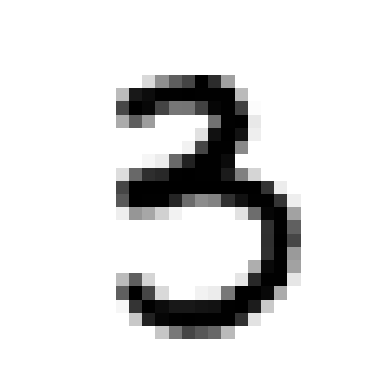

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # Required if you haven't loaded the data yet


# We'll use the training set for this example: X is x_train, y is y_train
X = x_train
y = y_train
# ---------------------------------------------

# Display the image from a random index
# 1. Get a random index. NumPy array length is len(X).
random_index = np.random.randint(0, len(X))

# 2. Extract the image and label directly using NumPy indexing.
# No .iloc or .values needed, as X and y are already NumPy arrays.
some_digit = X[random_index]
some_label = y[random_index]

# Display the image and the label
print(f"The label of the image at index {random_index} is: {some_label}\n")

# 3. Reshape the image (The Keras-loaded X is already (N, 28, 28), so no reshape is strictly necessary
# if you just plot X[random_index], but we keep the variable name for consistency)
some_digit_image = some_digit # X[random_index] is already (28, 28)

# 4. Use "binary" or "gray" colormap.
# Note: Keras default data is typically 0-255, so 'gray' or 'binary' is best.
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [7]:
import numpy as np
import tensorflow as tf
# Assuming you have loaded the data as standard Keras/NumPy arrays:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 1. Convert to float data type
# Standard Scaler works best on float data
X_train = x_train.astype(np.float32)
X_test = x_test.astype(np.float32)

# 2. Calculate the mean and standard deviation from the TRAINING DATA
# This is equivalent to scaler.fit(X_train)
mean_train = X_train.mean()
std_train = X_train.std()

# We must ensure we don't divide by zero if the data is constant
if std_train == 0:
    std_train = 1.0

# 3. Apply standardization to both training and test data
# This is equivalent to scaler.transform(X)
X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

print("--- Standardization Complete ---")
print(f"Mean of X_train after scaling: {X_train.mean():.4f}") # Should be close to 0
print(f"Std Dev of X_train after scaling: {X_train.std():.4f}") # Should be close to 1
print(f"Mean of X_test after scaling (using training mean): {X_test.mean():.4f}")

--- Standardization Complete ---
Mean of X_train after scaling: -0.0000
Std Dev of X_train after scaling: 1.0000
Mean of X_test after scaling (using training mean): 0.0060


In [8]:

from sklearn.neural_network import MLPClassifier

# Initialize the neural network
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation = 'relu',
                    solver='adam', max_iter=100, random_state=42)

In [10]:
import numpy as np
from sklearn.neural_network import MLPClassifier # Assuming this is your classifier

# --- Existing Data Shapes (Before Fix) ---
# X_train.shape is (60000, 28, 28)
# X_test.shape is (10000, 28, 28)

# 1. Store the number of samples (60000)
n_samples_train = X_train.shape[0]
n_samples_test = X_test.shape[0]
n_features = 28 * 28 # 784 pixels per image

# 2. Reshape (Flatten) the training and testing data

# Option A: Use .reshape()
X_train_flat = X_train.reshape(n_samples_train, n_features)
X_test_flat = X_test.reshape(n_samples_test, n_features)

# OR Option B (More common and concise): Use -1 to infer the sample count
# This is preferred as it is robust to different batch sizes
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print(f"Original X_train shape: {X_train.shape}")
print(f"Flattened X_train shape: {X_train_flat.shape}")

# 3. Fit the model using the flattened data
# Assuming 'mlp' is your initialized MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=50, random_state=42)
mlp.fit(X_train_flat, y_train)

print("\nModel trained successfully with flattened data!")

Original X_train shape: (60000, 28, 28)
Flattened X_train shape: (60000, 784)

Model trained successfully with flattened data!
